### Imports

In [14]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt


### Constants

In [24]:
MODEL_NAME = 'cnn_classifier'
MODEL_VERSION = 'v1.0'
SAVE_MODEL_PATH = f'models/{MODEL_NAME}_{MODEL_VERSION}.keras'
LOAD_MODEL = False

NO_CLASSES = 10
IMG_SIZE = 32
CHANNELS = 3

hyperparameters = {
    'learning_rate': 0.001,
    'epochs': 20,
    'batch_size': 64,

    'optimizer': 'adam',
    'loss_fn': 'categorical_crossentropy', # suitable for one-hot encoded labels
    'metrics': ['accuracy'],
}

# Loading and preprocessing data

In [7]:
# Loading the CIFAR-10 dataset
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the data between 0 and 1
x_train, x_test  = x_train / 255.0, x_test / 255.0

# One-hot encoding the labels
y_train = tf.keras.utils.to_categorical(y_train, NO_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NO_CLASSES)

# Building the model

In [ ]:
def build_cnn_v1(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), num_classes=NO_CLASSES):
    # Building the Convolutional Neural Network (CNN) model
    # - Convolutional layers to extract features from images
    # - MaxPooling layers to reduce the spatial dimensions of the feature maps
    #    - Goal: separate the feature extraction from reduction of dimensions
    # - Dropout layers to prevent overfitting
    return Sequential([
        # 1. Conv-Block
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # 2. Conv-Block
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # 3. Conv-Block
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

In [ ]:
if LOAD_MODEL:
    model = load_model(f'{MODEL_NAME}_{MODEL_VERSION}.h5')
else:
    model = build_cnn_v1()

model.compile(
    optimizer=hyperparameters['optimizer'],
    loss=hyperparameters['loss_fn'], 
    metrics=hyperparameters['metrics']
)

/Users/arneallwardt/Documents/-Studium/Master/Semester_2/SmartGraphics/Einsendeaufgabe2/smart_graphics_submission_2/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,13

 Total params: 1,343,018 (5.12 MB)

 Trainable params: 1,342,122 (5.12 MB)

 Non-trainable params: 896 (3.50 KB)

# Training & testing

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=hyperparameters['epochs'],
    batch_size=hyperparameters['batch_size'],
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 116ms/step - accuracy: 0.3501 - loss: 1.9768
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.5780 - loss: 1.1959
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 122ms/step - accuracy: 0.6651 - loss: 0.9560
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.7037 - loss: 0.8502
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 122ms/step - accuracy: 0.7357 - loss: 0.7666
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.7563 - loss: 0.7012
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.7729 - loss: 0.6546
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.7971 - loss: 0.5989
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.8134 - loss: 0.5418
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 132ms/step - accuracy: 0.8234 - loss: 0.5129
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 141ms/step - accuracy: 0.8303 - loss: 0.4851
Epoch 12/20
782/7

In [12]:
eval_loss, eval_accuracy = model.evaluate(x_test, y_test)
print(f"Accuracy on test set: {eval_accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7973 - loss: 0.6863
Accuracy on test set: 0.80


In [25]:
model.save(SAVE_MODEL_PATH)

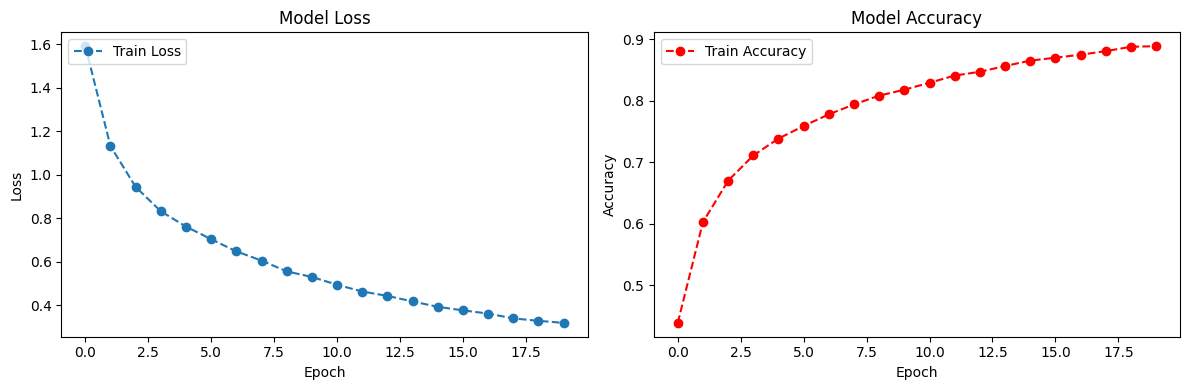

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 Zeile, 2 Spalten

# Loss-Plot
axs[0].plot(history.history['loss'], 'o--')
axs[0].set_title('Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend(['Train Loss'], loc='upper left')

# Accuracy-Plot
axs[1].plot(history.history['accuracy'], 'ro--')
axs[1].set_title('Model Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend(['Train Accuracy'], loc='upper left')

plt.tight_layout()
plt.show()
